In [518]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

In [519]:
practice = pd.read_csv('practice_dataset.csv')

In [520]:
practice.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       10000 non-null  float64
 1   b       10000 non-null  float64
 2   c       10000 non-null  float64
 3   d       10000 non-null  float64
 4   e       10000 non-null  float64
 5   f       10000 non-null  float64
 6   target  10000 non-null  float64
dtypes: float64(7)
memory usage: 547.0 KB


In [521]:
practice['target'].value_counts()

target
-23.804962     1
-158.554897    1
-69.630480     1
-77.556230     1
-93.973154     1
              ..
-31.255474     1
 59.863715     1
-130.700082    1
-44.931700     1
-90.809266     1
Name: count, Length: 10000, dtype: int64

In [522]:
practice.head()

,a,b,c,d,e,f,target
0,3.745401,7.472816,2.299983,6.743301,-4.021759,2.541710,-23.804962
1,9.507143,6.658242,-3.154880,5.133632,-8.103644,1.483551,-158.554897
2,7.319939,3.523078,-1.533603,9.680487,-7.472816,0.586397,-69.630480
3,5.986585,12.145333,1.632806,2.970806,-6.386577,2.209925,-77.556230
4,1.560186,9.532483,-0.179107,6.290708,-5.926933,1.256034,-93.973154


In [523]:
practice.duplicated().sum()

np.int64(0)

## **4. Model**

In [524]:
X_i = practice.drop('target', axis=1)
y = practice['target']

In [525]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    idx = np.random.permutation(len(X))
    split = int(len(X) * size)

    X_train = X.iloc[idx[:split]]
    X_test = X.iloc[idx[split:]]
    y_train = y.iloc[idx[:split]]
    y_test = y.iloc[idx[split:]]

    return X_train, X_test, y_train, y_test

In [526]:
X_train, X_test, y_train, y_test = split_data(X, y)
for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(8000, 6)
(2000, 6)
(8000,)
(2000,)


In [527]:
# X_train = (X_train - X_train.mean()) / (X_train.std() + 1e-9)
# X_test = (X_test - X_test.mean()) / (X_test.std() + 1e-9)

X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())
X_test = (X_test - X_test.min()) / (X_test.max() - X_test.min())


# X = (X_i - X_i.mean()) / (X_i.std() + 1e-9)
# X = (X_i - X_i.min()) / (X_i.max() - X_i.min())

In [528]:
class KNN:
    def __init__(self, k=3, p=2, weight='uniform'):
        self.k = k
        self.X_train = None
        self.y_train = None
        self.p = p
        self.weight = weight

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distance(self, x):
        if self.p == 1:
            distance = np.sum(np.abs(self.X_train - x), axis=1)
        else:
            distance = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        
        return distance
    def _neighboor(self, x):
        distance = self._distance(x)

        if len(distance) > self.k:
            neighbor_indices = np.argpartition(distance, self.k)[:self.k]
            sorted_indices = np.argsort(distance[neighbor_indices])
            neighbor_indices = neighbor_indices[sorted_indices]
        else:
            neighbor_indices = np.argsort(distance)[:self.k]
        
        return neighbor_indices, distance[neighbor_indices]
    
    def _predict_single(self, x):
        neighbor_indices, distance = self._neighboor(x)
        neighbor_target = self.y_train[neighbor_indices]

        if self.weight == 'uniform':
            prediction = np.mean(neighbor_target)
        else:
            weight = 1.0 / (distance + 1e-9)
            weight_norm = weight / np.sum(weight)
            prediction = np.dot(weight_norm, neighbor_target)
            
        #     if np.any(distance == 0):
        #         exact_match = neighbor_indices[distance == 0][0]
        #         return self.y_train[exact_match]

        #     weight = 1 / distance
        #     weight = weight / np.sum(weight)
        #     prediction = np.sum(weight * neighbor_target)
        
        return prediction

    def predict(self, X):
        X = np.array(X)
        prediction = np.array([self._predict_single(x) for x in X])

        return prediction

    def r2(self, X, y,):
        y_pred = self.predict(X)
        y_true = np.array(y)
        rss = np.sum((y_true - y_pred)**2)
        tss = np.sum((y_true - np.mean(y_true))**2)
        return 1 - (rss / tss)

In [529]:
def search(X_train, y_train, y_test, X_test):
    best_acc = 0
    best_k = {}

    for k in [3,5,7,9,11]:
        for p in [1,2]:
            for w in ['uniform' , 'weighted']:
                model = KNN(k=k, p=p, weight=w)
                model.fit(X_train, y_train)
                pred = model.predict(X_test)
                
                rss = sum((y_test - pred)**2)
                tss = sum((y_test - y_test.mean())**2)
                r2 = 1 - rss  / tss

                print(f'K: {k} - P: {p} - W: {w} - Score: {r2:.4f}')
    
                if r2 > best_acc:
                    best_acc = r2
                    best_k = {'k':k, 'p':p, 'w':w}
    print(f"K: {best_k.get('k')} - P: {best_k.get('p')} - Weight: {best_k.get('w')} - r2: {best_acc:.4f}")
    
    return best_k

In [530]:
best_k = search(X_train, y_train, y_test, X_test)

K: 3 - P: 1 - W: uniform - Score: 0.9190
K: 3 - P: 1 - W: weighted - Score: 0.9223
K: 3 - P: 2 - W: uniform - Score: 0.9171
K: 3 - P: 2 - W: weighted - Score: 0.9208
K: 5 - P: 1 - W: uniform - Score: 0.9289
K: 5 - P: 1 - W: weighted - Score: 0.9333
K: 5 - P: 2 - W: uniform - Score: 0.9261
K: 5 - P: 2 - W: weighted - Score: 0.9302
K: 7 - P: 1 - W: uniform - Score: 0.9300
K: 7 - P: 1 - W: weighted - Score: 0.9347
K: 7 - P: 2 - W: uniform - Score: 0.9268
K: 7 - P: 2 - W: weighted - Score: 0.9314
K: 9 - P: 1 - W: uniform - Score: 0.9301
K: 9 - P: 1 - W: weighted - Score: 0.9349
K: 9 - P: 2 - W: uniform - Score: 0.9261
K: 9 - P: 2 - W: weighted - Score: 0.9311
K: 11 - P: 1 - W: uniform - Score: 0.9289
K: 11 - P: 1 - W: weighted - Score: 0.9339
K: 11 - P: 2 - W: uniform - Score: 0.9259
K: 11 - P: 2 - W: weighted - Score: 0.9310
K: 9 - P: 1 - Weight: weighted - r2: 0.9349


In [531]:
# model_weighted = KNN(k=best_k.get('k'), p=best_k.get('p'), weight=best_k.get('w'))
# model_weighted.fit(X_train, y_train)

model = KNN(k=best_k.get('k'), p=best_k.get('p'), weight='uniform')
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [532]:
def evaluate(y_true, y_pred, title='Train'):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)

    rss = sum((y_true - y_pred)**2)
    tss = sum((y_true - y_true.mean())**2)
    r2 = 1 - (rss  / tss)
    
    print(f'\nEvaluasi Data {title}')
    print(f'MAE     : {mae:.4f}')
    print(f'MSE     : {mse:.4f}')
    print(f'RMSE    : {rmse:.4f}')
    print(f'R2      : {r2:.4f}')

In [533]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')


Evaluasi Data Train
MAE     : 13.2430
MSE     : 307.5384
RMSE    : 17.5368
R2      : 0.9426

Evaluasi Data Test
MAE     : 14.8244
MSE     : 382.7918
RMSE    : 19.5651
R2      : 0.9301


In [534]:
def plot(y_true ,y_pred, title='Train'):
    plt.figure(figsize=(12,8))
    plt.title(f'Scatter Plot Prediksi vs Aktual {title}', fontsize='18')
    plt.scatter(y_pred_test.flatten(), y_test, alpha=0.7, label='Data Aktual', edgecolors='black')
    plt.plot([y_pred_test.min(), y_pred_test.max()], [y_test.min(), y_test.max()], '--r', label='Prediksi')
    plt.legend()
    plt.show()

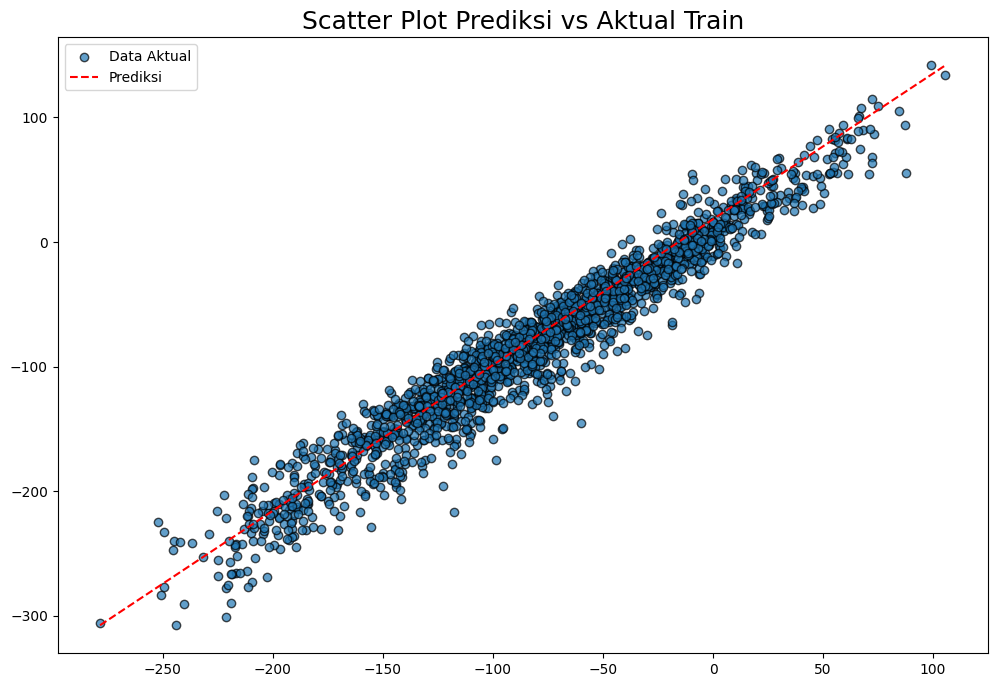

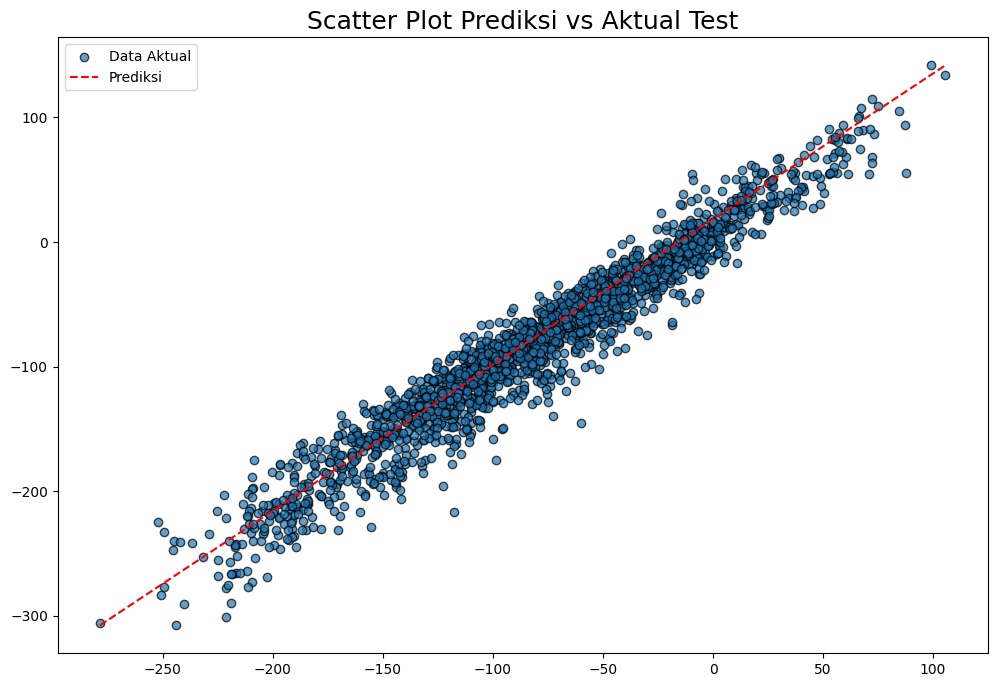

In [535]:
plot(y_train, y_pred_train)
plot(y_test, y_pred_test, title='Test')

In [554]:
col = X.columns.to_list()
n_col = len(col)

def submit():
    try:
        input_data =[]
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)

        input_df = pd.DataFrame([input_data], columns=col)
        input_scaled = (input_df - X_train.min()) / (X_train.max() - X_train.min())
        prediction = model.predict(input_scaled)
        messagebox.showinfo('Hasil Prediksi', f'Target: {prediction[0]:.3f}')
    except ValueError:
        messagebox.showerror('Error', 'Input Yang Bener')

root = tk.Tk()
root.configure(bg='#131313')
root.title('Prediksi Target')
root.geometry('480x550')
entries = []

frame = tk.Frame(root)
frame.configure(bg='#131313')
frame.place(relx=0.5, rely=0.4, anchor='center')

title_label = tk.Label(
    frame,
    text='Prediksi Target 🎯',
    font=('Helvetica', 23, 'bold'),
    bg='#131313',
    fg='#fefffa'
)
title_label.grid(row=0, column=0, columnspan=2)

label_instruksi = tk.Label(
    frame,
    text='Masukan Data dibawah 👇',
    font=('Helvetica', 10),
    bg='#131313',
    fg='#857c7b'
)
label_instruksi.grid(row=1, column=0, columnspan=2, pady=5)

for i, feature in enumerate(col):
    label = tk.Label(
        frame, 
        text=f'{feature}    :',
        font=('Helvetica', 18),
        bg='#131313',
        fg='#fefffa'
    )

    label.grid(row=i+2, column=0, padx=5, pady=5, sticky='w')
    entry = tk.Entry(
        frame,
        font=('Helvetica', 12),
        bg='#2e2e30',
        fg='#fefffa'
    )
    entry.grid(row=i+2, column=1, padx=5)
    entries.append(entry)

button = tk.Button(
    frame,
    text='Prediksi',
    font=('Helvetica', 20),
    bg='#18ab27',
    fg='#fefffa',
    command=submit
)
button.grid(row=n_col+2, column=0, columnspan=2, padx=5, pady=(30,5))

root.mainloop()

In [537]:
X_test.head(5)

,a,b,c,d,e,f
399,0.755000,0.490895,0.623391,0.922070,0.622740,0.237921
7247,0.863313,0.779853,0.138438,0.593630,0.849142,0.530905
6406,0.329197,0.237278,0.633157,0.175865,0.217869,0.482517
882,0.019591,0.386171,0.762046,0.546868,0.321340,0.997098
3565,0.725440,0.428009,0.668254,0.496563,0.830982,0.400295


In [539]:
pd.DataFrame(y_pred_test).head(5)

,0
0,-29.085433
1,-199.615922
2,-42.981948
3,-46.300871
4,-65.764595
